# Convergence / Sample-Size Study for MMLU-Pro

**Goal:** find the smallest sample size *N* such that calibration metrics (ECE, AUROC, confidence-accuracy gap) and accuracy are stable to within tolerance across bootstrap resamples.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')


## Configuration

Edit `PILOT_FILES` to point at the CSVs from the models you've already run on the full MMLU-Pro corpus. Each CSV needs the same columns as your existing pipeline plus a `Category` column.


In [ ]:
# CSVs from the mdodels run on MMLU 
PILOT_FILES = {
    '1B': 'mega_1_lama_instruct.csv',
    '3B':  'mega_3_qwen_base.csv',
    '8B':   'mega_8_lama_base.csv',
    '32B':  'mega_32_qwen_instruct.csv',
    '70B':  'mega_70_lama_instruct.csv',
    '72B':  'mega_72_qwen_base.csv',

}

#confidnece metrics compared
CONF_METRICS = {
    'Entropy_as_confidence': 100,
    'Letter_MSP_confidence': 100,
    'Margin_renorm_ABCD':  100,   
    'verbal_integer_found':   1,
    'p1_probability':       100,
    'p_true_probability':   100,
}

#Number of samples tested:
SAMPLE_SIZES = [1000, 1500, 2000, 2500, 2700, 3000, 5000]
N_BOOTSTRAPS = 200          
RNG_SEED     = 42

# Tolerance thresholds for 'stable enough'
TOL_ECE_PP   = 1.0          # ECE std (in percentage points)
TOL_AUROC    = 0.01
TOL_GAP_PP   = 1.0
TOL_ACC_PP   = 1.0          # accuracy std (in percentage points)


## Metric functions

`compute_ece` matches the binning logic in your existing notebook (10 equal-width bins, 0–1 confidence). `compute_metrics` returns four numbers: ECE, AUROC, confidence-accuracy gap, and **accuracy** — all in interpretable units.


In [ ]:
def compute_ece(conf_0_1, correct, n_bins=10):
    """Expected Calibration Error, returned in percentage points."""
    conf_pct = conf_0_1 * 100
    bins = np.linspace(0, 100, n_bins + 1)
    bin_idx = np.digitize(conf_pct, bins) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    n = len(conf_0_1)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.any():
            acc_b  = correct[mask].mean()
            conf_b = conf_0_1[mask].mean()
            ece += mask.sum() / n * abs(acc_b - conf_b)
    return ece * 100


def compute_metrics(df, metric_col, scale):
    """
    Returns (ECE pp, AUROC, conf-acc gap pp, accuracy pp) for a single dataframe.
    Accuracy is the same for every confidence metric (it's just is_correct.mean())
    but we return it here so it sits alongside the others in the same loop.
    """
    sub = df.dropna(subset=[metric_col, 'is_correct']).copy()
    if len(sub) < 20:
        return np.nan, np.nan, np.nan, np.nan
    conf_raw = pd.to_numeric(sub[metric_col], errors='coerce')
    conf_0_1 = (conf_raw * scale / 100).clip(0, 1).values
    correct  = sub['is_correct'].astype(int).values

    ece = compute_ece(conf_0_1, correct)
    try:
        auroc = roc_auc_score(correct, conf_0_1)
    except ValueError:
        auroc = np.nan
        #this is where gap is devided it the average confidence - average mean, absolute values and turned into percentage
    gap = (conf_0_1.mean() - correct.mean()) * 100
    acc = correct.mean() * 100
    return ece, auroc, gap, acc


## Stratified sampler

Proportional stratification by `Category` — each category contributes a slice proportional to its share of the full dataset. This keeps the category mix stable across bootstraps, which matters because Dunning–Kruger is fundamentally about competence variation across domains.


In [10]:
def stratified_sample(df, n, rng):
    """
    Proportional stratified sample by Category. Each category contributes
    a number of rows proportional to its full-dataset share (with rounding
    so the total lands at n).
    """
    cats = df['Category'].value_counts()
    proportions = cats / cats.sum()
    target = (proportions * n).round().astype(int)

    # Adjust for rounding drift so we hit exactly n
    diff = n - target.sum()
    if diff != 0:
        order = target.sort_values(ascending=(diff < 0)).index.tolist()
        for cat in order:
            if diff == 0:
                break
            step = 1 if diff > 0 else -1
            target[cat] += step
            diff -= step

    samples = []
    for cat, k in target.items():
        if k <= 0:
            continue
        pool = df[df['Category'] == cat]
        k = min(k, len(pool))
        samples.append(pool.sample(n=k, random_state=rng.integers(0, 2**31)))
    return pd.concat(samples, ignore_index=True)


## Convergence study

For each *N*, draw `N_BOOTSTRAPS` stratified samples and compute every metric on each. We then look at the **standard deviation** of each metric across bootstraps — that's the noise floor at that *N*. Note that accuracy is a property of the sample (not the confidence metric) but we record it once per metric anyway for plotting convenience.


In [11]:
def run_convergence(df, model_label, sample_sizes, n_boots, seed):
    """
    For each sample size, do n_boots stratified bootstrap draws and compute
    metric mean + std across them.
    Returns long-format DataFrame: model, metric, N, stat, mean, std.
    """
    rng = np.random.default_rng(seed)
    rows = []
    for n in sample_sizes:
        if n > len(df):
            print(f'  Skipping N={n}: only {len(df)} rows in dataset')
            continue
        store = {col: {'ece': [], 'auroc': [], 'gap': [], 'acc': []}
                 for col in CONF_METRICS}
        for _ in range(n_boots):
            sample = stratified_sample(df, n, rng)
            for col, scale in CONF_METRICS.items():
                ece, auroc, gap, acc = compute_metrics(sample, col, scale)
                store[col]['ece'].append(ece)
                store[col]['auroc'].append(auroc)
                store[col]['gap'].append(gap)
                store[col]['acc'].append(acc)

        for col in CONF_METRICS:
            for stat_name in ['ece', 'auroc', 'gap', 'acc']:
                arr = np.array(store[col][stat_name])
                rows.append({
                    'model':  model_label,
                    'metric': col,
                    'N':      n,
                    'stat':   stat_name,
                    'mean':   np.nanmean(arr),
                    'std':    np.nanstd(arr),
                })
        print(f'  N={n:>5d}  done')
    return pd.DataFrame(rows)


## Load pilot data and run


In [12]:
print('Loading pilot models...')
dfs = {}
for label, path in PILOT_FILES.items():
    df = pd.read_csv(path)
    if 'letter_llm_outputted_detected' in df.columns:
        mask = (df['letter_llm_outputted_detected'].isna() |
                (df['letter_llm_outputted_detected'].astype(str).str.strip() == ''))
        df = df[~mask].copy()
    dfs[label] = df
    print(f"  {label}: {len(df)} rows, {df['Category'].nunique()} categories")


Loading pilot models...
  1B: 6232 rows, 28 categories
  3B: 6233 rows, 28 categories
  8B: 6095 rows, 28 categories
  32B: 6233 rows, 28 categories
  70B: 6233 rows, 28 categories
  72B: 6233 rows, 28 categories


In [13]:
print('Running convergence study...')
all_results = []
for label, df in dfs.items():
    print(f'\nModel {label}:')
    res = run_convergence(df, label, SAMPLE_SIZES, N_BOOTSTRAPS, RNG_SEED)
    all_results.append(res)
results = pd.concat(all_results, ignore_index=True)
results.to_csv('convergence_results.csv', index=False)
print('\nSaved → convergence_results.csv')
results.head()


Running convergence study...

Model 1B:
  N= 1000  done
  N= 1500  done
  N= 2000  done
  N= 2500  done
  N= 2700  done
  N= 3000  done
  N= 5000  done

Model 3B:
  N= 1000  done
  N= 1500  done
  N= 2000  done
  N= 2500  done
  N= 2700  done
  N= 3000  done
  N= 5000  done

Model 8B:
  N= 1000  done
  N= 1500  done
  N= 2000  done
  N= 2500  done
  N= 2700  done
  N= 3000  done
  N= 5000  done

Model 32B:
  N= 1000  done
  N= 1500  done
  N= 2000  done
  N= 2500  done
  N= 2700  done
  N= 3000  done
  N= 5000  done

Model 70B:
  N= 1000  done
  N= 1500  done
  N= 2000  done
  N= 2500  done
  N= 2700  done
  N= 3000  done
  N= 5000  done

Model 72B:
  N= 1000  done
  N= 1500  done
  N= 2000  done
  N= 2500  done
  N= 2700  done
  N= 3000  done
  N= 5000  done

Saved → convergence_results.csv


,model,metric,N,stat,mean,std
0,1B,Entropy_as_confidence,1000,ece,17.702867,1.310967
1,1B,Entropy_as_confidence,1000,auroc,0.677641,0.015565
2,1B,Entropy_as_confidence,1000,gap,-15.808403,1.227251
3,1B,Entropy_as_confidence,1000,acc,46.063500,1.315035
4,1B,Letter_MSP_confidence,1000,ece,12.952137,1.166184


## Plot 1 — ECE std vs N

ECE is the most sample-hungry metric (it depends on binning) and almost always determines your final *N*.


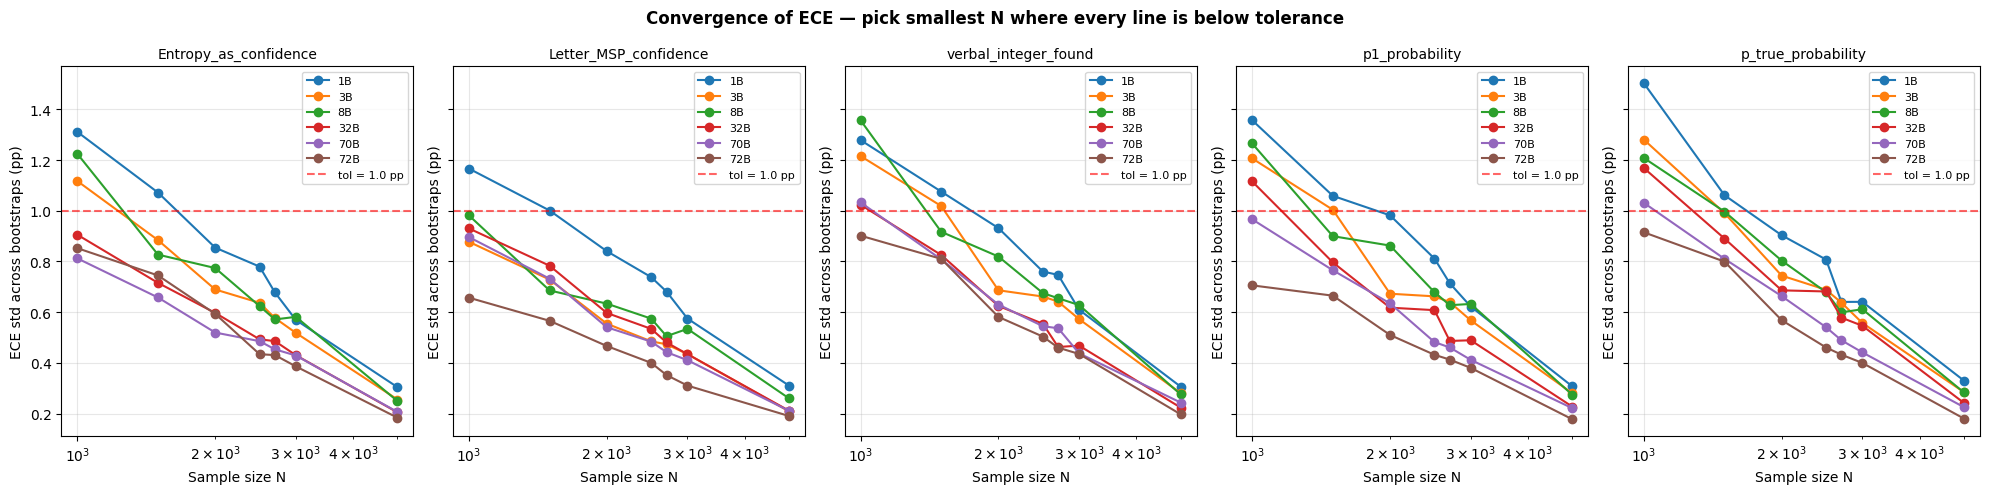

In [24]:
fig, axes = plt.subplots(1, len(CONF_METRICS),
                         figsize=(4 * len(CONF_METRICS), 5), sharey=True)
if len(CONF_METRICS) == 1:
    axes = [axes]
for ax, col in zip(axes, CONF_METRICS):
    sub = results[(results['metric'] == col) & (results['stat'] == 'ece')]
    for label in PILOT_FILES:
        line = sub[sub['model'] == label].sort_values('N')
        ax.plot(line['N'], line['std'], marker='o', label=label)
    ax.axhline(TOL_ECE_PP, color='red', ls='--', alpha=0.6,
               label=f'tol = {TOL_ECE_PP} pp')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Sample size N')
    ax.set_ylabel('ECE std across bootstraps (pp)')
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Convergence of ECE — pick smallest N where every line is below tolerance',
             fontweight='bold')
fig.tight_layout()
fig.savefig('convergence_ece.png', dpi=150, bbox_inches='tight')
plt.show()


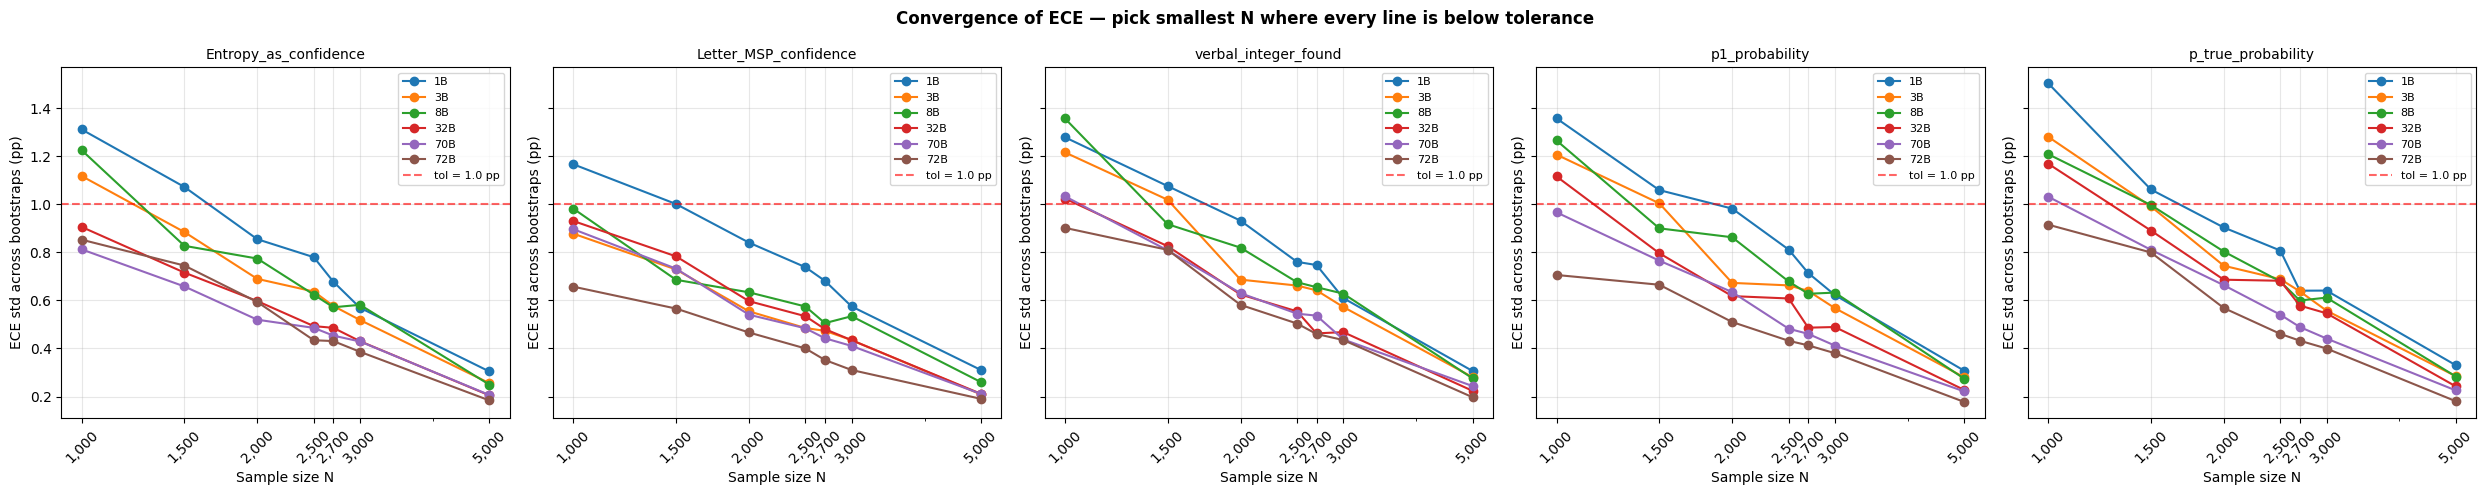

In [29]:
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, len(CONF_METRICS),
                         figsize=(5 * len(CONF_METRICS), 5), sharey=True)
if len(CONF_METRICS) == 1:
    axes = [axes]

for ax, col in zip(axes, CONF_METRICS):
    sub = results[(results['metric'] == col) & (results['stat'] == 'ece')]
    for label in PILOT_FILES:
        line = sub[sub['model'] == label].sort_values('N')
        ax.plot(line['N'], line['std'], marker='o', label=label)
    ax.axhline(TOL_ECE_PP, color='red', ls='--', alpha=0.6,
               label=f'tol = {TOL_ECE_PP} pp')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Sample size N')
    ax.set_ylabel('ECE std across bootstraps (pp)')
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    # Put a tick at every actual N value in the data
    all_ns = sorted(results['N'].unique())
    ax.set_xticks(all_ns)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: ''))
    ax.tick_params(axis='x', labelrotation=45)

fig.suptitle('Convergence of ECE — pick smallest N where every line is below tolerance',
             fontweight='bold')
fig.tight_layout()
fig.savefig('convergence_ece.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 — Accuracy std vs N

Accuracy converges *much* faster than ECE — usually by N≈500 the std is below 1pp. Useful as a sanity check (if accuracy std looks weird, your sampler has a bug) and as a reportable headline number for your dissertation.


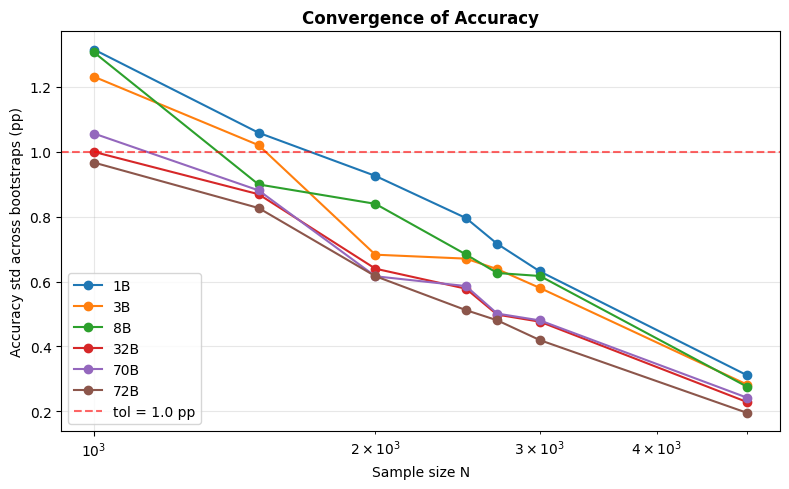

In [25]:
# Accuracy is identical across confidence-metric rows for the same model+N,
# so we just take the first metric's values to avoid clutter.
first_metric = list(CONF_METRICS.keys())[0]
fig, ax = plt.subplots(figsize=(8, 5))
sub = results[(results['metric'] == first_metric) & (results['stat'] == 'acc')]
for label in PILOT_FILES:
    line = sub[sub['model'] == label].sort_values('N')
    ax.plot(line['N'], line['std'], marker='o', label=label)
ax.axhline(TOL_ACC_PP, color='red', ls='--', alpha=0.6,
           label=f'tol = {TOL_ACC_PP} pp')
ax.set_title('Convergence of Accuracy', fontweight='bold')
ax.set_xlabel('Sample size N')
ax.set_ylabel('Accuracy std across bootstraps (pp)')
ax.set_xscale('log')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig('convergence_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


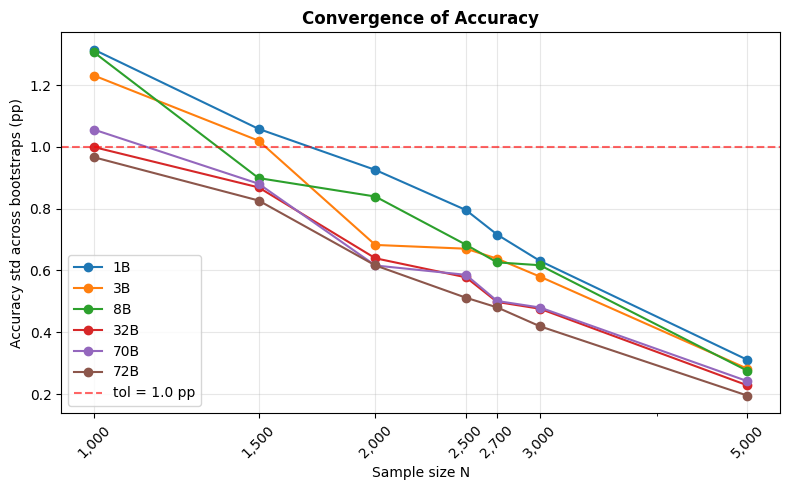

In [27]:
from matplotlib.ticker import FuncFormatter

all_ns = sorted(results['N'].unique())
x_formatter = FuncFormatter(lambda x, _: f'{int(x):,}')

first_metric = list(CONF_METRICS.keys())[0]
fig, ax = plt.subplots(figsize=(8, 5))
sub = results[(results['metric'] == first_metric) & (results['stat'] == 'acc')]
for label in PILOT_FILES:
    line = sub[sub['model'] == label].sort_values('N')
    ax.plot(line['N'], line['std'], marker='o', label=label)
ax.axhline(TOL_ACC_PP, color='red', ls='--', alpha=0.6,
           label=f'tol = {TOL_ACC_PP} pp')
ax.set_title('Convergence of Accuracy', fontweight='bold')
ax.set_xlabel('Sample size N')
ax.set_ylabel('Accuracy std across bootstraps (pp)')
ax.set_xscale('log')
ax.set_xticks(all_ns)
ax.xaxis.set_major_formatter(x_formatter)
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: ''))
ax.tick_params(axis='x', labelrotation=45)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig('convergence_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 — All four stats side by side

Quick visual of how each metric tightens with N. Anything below the red dashed line is within tolerance.


In [31]:
PILOT_FILES

{'1B': 'mega_1_lama_instruct.csv',
 '3B': 'mega_3_qwen_base.csv',
 '8B': 'mega_8_lama_base.csv',
 '32B': 'mega_32_qwen_instruct.csv',
 '70B': 'mega_70_lama_instruct.csv',
 '72B': 'mega_72_qwen_base.csv'}

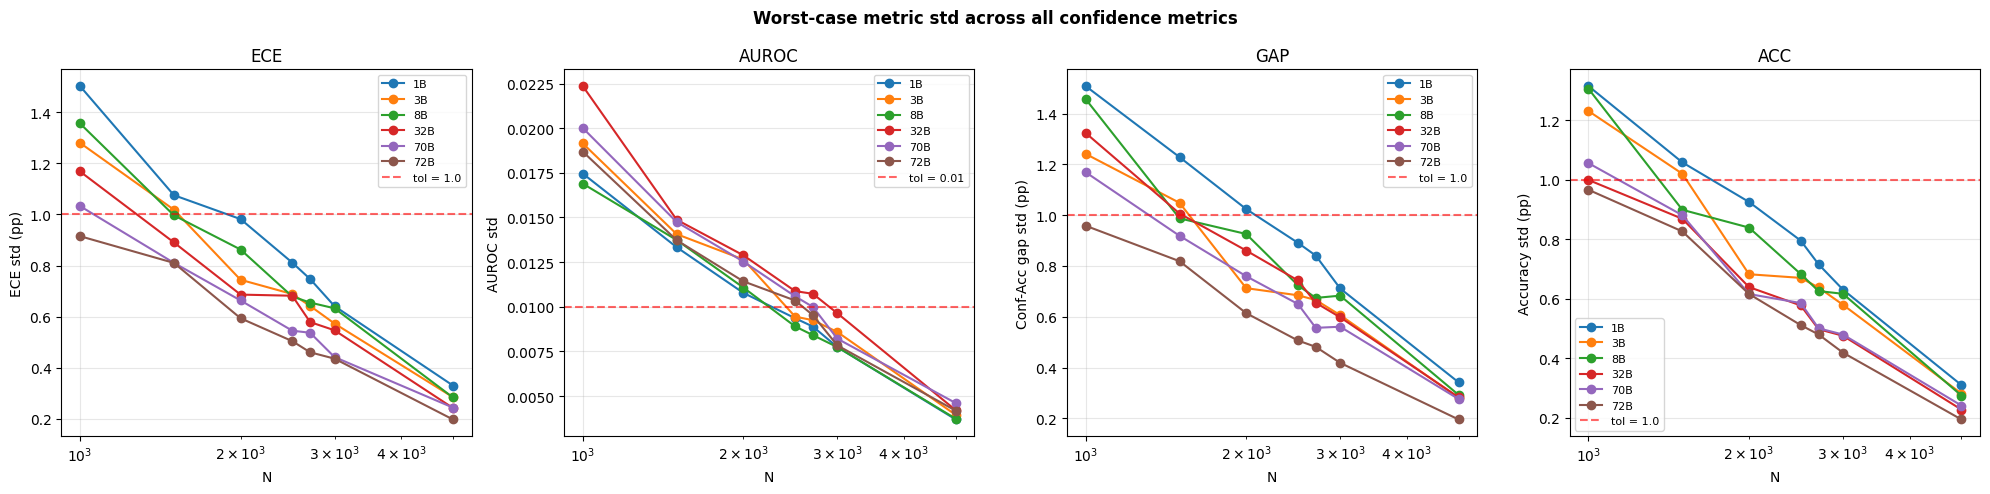

In [16]:
stat_info = {
    'ece':   ('ECE std (pp)',      TOL_ECE_PP),
    'auroc': ('AUROC std',         TOL_AUROC),
    'gap':   ('Conf-Acc gap std (pp)', TOL_GAP_PP),
    'acc':   ('Accuracy std (pp)', TOL_ACC_PP),
}
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# Show the worst-case metric across all confidence metrics for each model
for ax, (stat, (ylabel, tol)) in zip(axes, stat_info.items()):
    for label in PILOT_FILES:
        sub = results[(results['model'] == label) & (results['stat'] == stat)]
        # Worst std across all confidence metrics at each N
        worst = sub.groupby('N')['std'].max().reset_index()
        ax.plot(worst['N'], worst['std'], marker='o', label=label)
    ax.axhline(tol, color='red', ls='--', alpha=0.6, label=f'tol = {tol}')
    ax.set_title(stat.upper())
    ax.set_xlabel('N')
    ax.set_ylabel(ylabel)
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Worst-case metric std across all confidence metrics',
             fontweight='bold')
fig.tight_layout()
fig.savefig('convergence_all_stats.png', dpi=150, bbox_inches='tight')
plt.show()


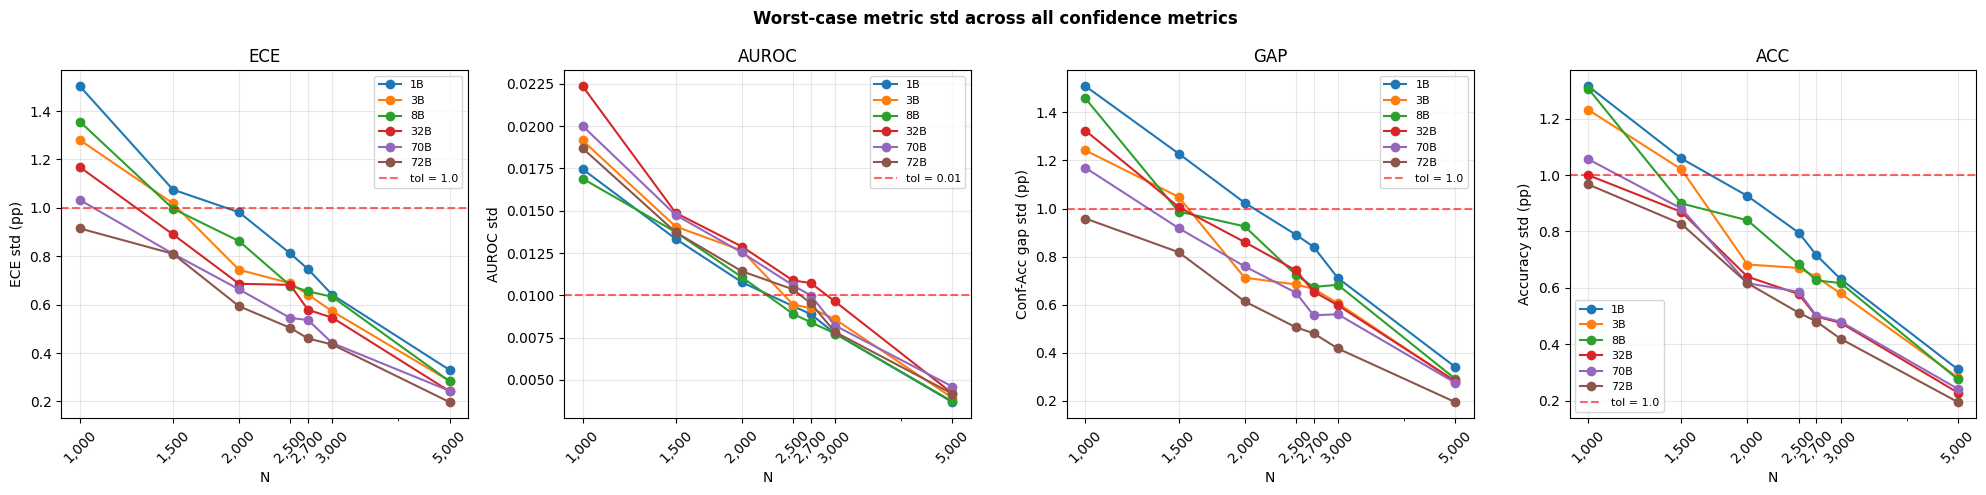

In [28]:
from matplotlib.ticker import FuncFormatter

all_ns = sorted(results['N'].unique())
x_formatter = FuncFormatter(lambda x, _: f'{int(x):,}')

stat_info = {
    'ece':   ('ECE std (pp)',          TOL_ECE_PP),
    'auroc': ('AUROC std',             TOL_AUROC),
    'gap':   ('Conf-Acc gap std (pp)', TOL_GAP_PP),
    'acc':   ('Accuracy std (pp)',     TOL_ACC_PP),
}
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (stat, (ylabel, tol)) in zip(axes, stat_info.items()):
    for label in PILOT_FILES:
        sub = results[(results['model'] == label) & (results['stat'] == stat)]
        worst = sub.groupby('N')['std'].max().reset_index()
        ax.plot(worst['N'], worst['std'], marker='o', label=label)
    ax.axhline(tol, color='red', ls='--', alpha=0.6, label=f'tol = {tol}')
    ax.set_title(stat.upper())
    ax.set_xlabel('N')
    ax.set_ylabel(ylabel)
    ax.set_xscale('log')
    ax.set_xticks(all_ns)
    ax.xaxis.set_major_formatter(x_formatter)
    ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: ''))
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Worst-case metric std across all confidence metrics',
             fontweight='bold')
fig.tight_layout()
fig.savefig('convergence_all_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## Recommendation

Print the smallest *N* where **every** metric on **every** model is below tolerance. That's the number to use for your full evaluation across all models on MMLU-Pro.


In [32]:
print('=' * 70)
print('RECOMMENDATION')
print('=' * 70)
print(f"{'N':>6} | {'ECE':>8} | {'AUROC':>8} | {'Gap':>8} | {'Acc':>8} | Verdict")
print('-' * 70)

stable_ns = []
for n in SAMPLE_SIZES:
    sub = results[results['N'] == n]
    worst_ece   = sub[sub['stat'] == 'ece']['std'].max()
    worst_auroc = sub[sub['stat'] == 'auroc']['std'].max()
    worst_gap   = sub[sub['stat'] == 'gap']['std'].max()
    worst_acc   = sub[sub['stat'] == 'acc']['std'].max()

    ok_ece   = worst_ece   < TOL_ECE_PP
    ok_auroc = worst_auroc < TOL_AUROC
    ok_gap   = worst_gap   < TOL_GAP_PP
    ok_acc   = worst_acc   < TOL_ACC_PP
    all_ok = all([ok_ece, ok_auroc, ok_gap, ok_acc])
    if all_ok:
        stable_ns.append(n)

    verdict = '✓ STABLE' if all_ok else '✗'
    print(f'{n:>6} | {worst_ece:>8.2f} | {worst_auroc:>8.4f} | '
          f'{worst_gap:>8.2f} | {worst_acc:>8.2f} | {verdict}')

print()
if stable_ns:
    chosen = min(stable_ns)
    print(f'→ Use N = {chosen} for the full evaluation across all 30 models.')
else:
    print('→ No tested N hit tolerance — extend SAMPLE_SIZES upward.')


RECOMMENDATION
     N |      ECE |    AUROC |      Gap |      Acc | Verdict
----------------------------------------------------------------------
  1000 |     1.50 |   0.0224 |     1.51 |     1.32 | ✗
  1500 |     1.08 |   0.0149 |     1.23 |     1.06 | ✗
  2000 |     0.98 |   0.0129 |     1.02 |     0.93 | ✗
  2500 |     0.81 |   0.0109 |     0.89 |     0.80 | ✗
  2700 |     0.75 |   0.0107 |     0.84 |     0.72 | ✗
  3000 |     0.64 |   0.0096 |     0.71 |     0.63 | ✓ STABLE
  5000 |     0.33 |   0.0046 |     0.34 |     0.31 | ✓ STABLE

→ Use N = 3000 for the full evaluation across all 30 models.


## Next step test MMLU-PRO
The results tell us at what number of questions do our answer vary minimally. this can then inform how many questions is needed for MMLU-Pro to not worry that the effects are influenced by a lower sample size.
